Loaded load_df:
                    load_kw
Date/Time                  
2024-01-01 00:15:00   67.33
2024-01-01 00:30:00   75.35
2024-01-01 00:45:00   82.55
2024-01-01 01:00:00    81.4
2024-01-01 01:15:00   80.23

Columns in cost_df:
Index(['load_kw', 'is_peak', 'energy_price_eur_mwh', 'energy_kwh_interval',
       'energy_mwh_interval', 'energy_cost_eur_interval',
       'atr_cost_eur_interval', 'subtotal_eur_interval', 'tax_eur_interval',
       'total_energy_related_eur_interval', 'demand_charge_eur_interval',
       'total_cost_eur_interval', 'monthly_peak_kw',
       'demand_charge_eur_month'],
      dtype='object')

Baseline annual cost [EUR]: 217728.45

------ SANITY CHECK ------
Total energy billed [MWh]: 1555.506
Total cost billed [EUR]: 218749.43
Effective price [€/MWh]: 140.63
Data starts: 2024-01-01 00:15:00
Data ends:   2025-01-02 00:00:00
Total intervals: 35232
------------------------------


Candidate actions (sorted by payback):
                                   name  

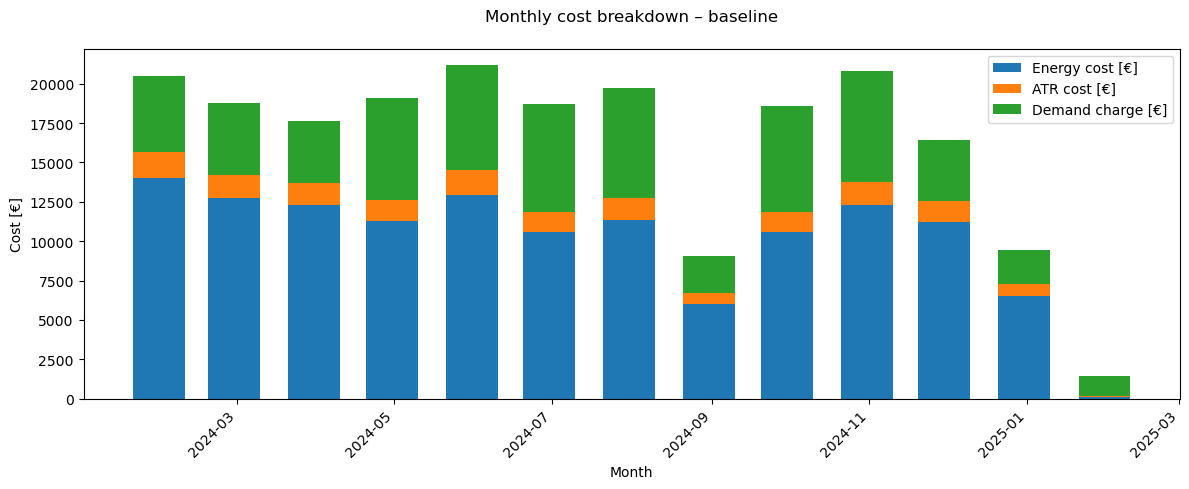

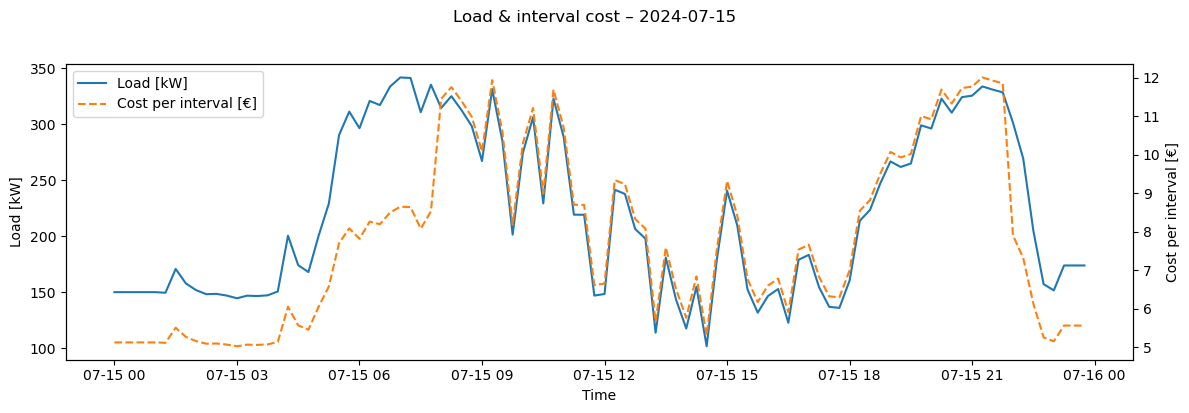

In [17]:
import pandas as pd
import numpy as np
from dataclasses import dataclass
import matplotlib.pyplot as plt
from typing import Tuple, Dict

# =========================================================
# 0. LOAD INTERVAL DATA (YOUR ENLIT EXCEL)
# =========================================================

LOAD_FILE = "/Users/mainakde/Downloads/Enlit/LoadProfile_Final_ENLIT.xlsx"


def load_interval_data(
    path: str = LOAD_FILE,
    ts_col: str = "Date/Time",
    load_col: str = "L1 Site",
    freq_hint: str = "15min",
) -> pd.DataFrame:
    """
    Reads the industrial site's interval data and returns a clean dataframe:
      index: timestamp
      column: 'load_kw'
    """
    df = pd.read_excel(path)

    # Map case-insensitive column names
    cols_lower = {c.lower(): c for c in df.columns}
    if ts_col.lower() not in cols_lower:
        raise ValueError(
            f"Timestamp column '{ts_col}' not found. Available: {df.columns.tolist()}"
        )
    if load_col.lower() not in cols_lower:
        raise ValueError(
            f"Load column '{load_col}' not found. Available: {df.columns.tolist()}"
        )

    tcol = cols_lower[ts_col.lower()]   # e.g. "Date/Time"
    lcol = cols_lower[load_col.lower()] # e.g. "L1 Site"

    # Keep only time + load to avoid resampling non-numerics
    df = df[[tcol, lcol]].copy()

    # Parse timestamps – format matches "2024-01-01 00:15:00"
    df[tcol] = pd.to_datetime(
        df[tcol],
        format="%Y-%m-%d %H:%M:%S",
        errors="coerce",
    )
    df = df.dropna(subset=[tcol])
    df = df.sort_values(tcol)
    df = df.set_index(tcol)

    # Normalize frequency – resample only numeric column
    if freq_hint:
        df = df.resample(freq_hint)[[lcol]].mean()

    # Standard name for downstream functions
    df = df.rename(columns={lcol: "load_kw"})
    return df


# =========================================================
# 1. TARIFF CONFIG
# =========================================================

@dataclass
class TariffConfig:
    name: str
    # Energy prices (€/MWh)
    price_peak: float
    price_offpeak: float

    # Demand charge (€/kW per month)
    demand_price_eur_per_kw_month: float

    # Regulated / ATR components (€/MWh)
    atr_eur_per_mwh: float = 0.0

    # Taxes as fraction of subtotal, e.g. 0.05 = 5%
    tax_rate: float = 0.0

    # Peak / off-peak hours (local time)
    peak_start_hour: int = 8   # 08:00
    peak_end_hour: int = 22    # 22:00


SPANISH_SAMPLE_TARIFF = TariffConfig(
    name="ES_Industrial_Placeholder",
    price_peak=100.0,          # €/MWh
    price_offpeak=60.0,        # €/MWh
    demand_price_eur_per_kw_month=8.0,
    atr_eur_per_mwh=10.0,
    tax_rate=0.05,
    peak_start_hour=8,
    peak_end_hour=22,
)


def is_peak_hour(ts, tariff: TariffConfig) -> bool:
    """Return True if timestamp is in peak hours under the given tariff."""
    h = ts.hour
    return (h >= tariff.peak_start_hour) and (h < tariff.peak_end_hour)


# =========================================================
# 2. COST ENGINE (ENERGY + DEMAND)
# =========================================================

def add_energy_price_column(
    df: pd.DataFrame,
    tariff: TariffConfig = SPANISH_SAMPLE_TARIFF,
    spot_price_eur_mwh: pd.Series | None = None,
) -> pd.DataFrame:
    """
    Add:
      - is_peak (bool)
      - energy_price_eur_mwh  (€/MWh)

    If spot_price_eur_mwh is provided (Series indexed like df.index),
    it is used as the energy price. Otherwise we fall back to
    peak/off-peak prices from the tariff.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("add_energy_price_column expects a DatetimeIndex.")

    df = df.copy()

    # Always compute is_peak for info / scenarios
    df["is_peak"] = df.index.map(lambda ts: is_peak_hour(ts, tariff))

    if spot_price_eur_mwh is not None:
        # Align spot prices to df index (forward-fill)
        spot_aligned = (
            spot_price_eur_mwh
            .sort_index()
            .reindex(df.index, method="ffill")
        )
        df["energy_price_eur_mwh"] = spot_aligned.values
    else:
        # Classic TOU tariff
        df["energy_price_eur_mwh"] = np.where(
            df["is_peak"], tariff.price_peak, tariff.price_offpeak
        )

    return df


def compute_interval_costs(
    df: pd.DataFrame,
    tariff: TariffConfig = SPANISH_SAMPLE_TARIFF,
    spot_price_eur_mwh: pd.Series | None = None,
) -> pd.DataFrame:
    """
    From 'load_kw' and time index, build interval energy, energy cost, ATR, and taxes.
    Optionally uses a spot price time series instead of static peak/off-peak prices.
    """
    if "load_kw" not in df.columns:
        raise KeyError("compute_interval_costs expects 'load_kw' column.")
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("compute_interval_costs expects DatetimeIndex.")

    df = df.copy()
    df = add_energy_price_column(df, tariff, spot_price_eur_mwh=spot_price_eur_mwh)

    # Interval duration in hours
    dt_minutes = df.index.to_series().diff().dt.total_seconds() / 60.0
    if dt_minutes.isna().all():
        raise ValueError("Could not infer interval length from index.")
    dt_minutes.iloc[0] = dt_minutes.median()
    hours = dt_minutes / 60.0

    # Interval energy in kWh and MWh
    df["energy_kwh_interval"] = df["load_kw"] * hours
    df["energy_mwh_interval"] = df["energy_kwh_interval"] / 1000.0

    # Energy cost (spot or TOU price)
    df["energy_cost_eur_interval"] = (
        df["energy_kwh_interval"] * df["energy_price_eur_mwh"] / 1000.0
    )

    # ATR cost
    df["atr_cost_eur_interval"] = (
        df["energy_kwh_interval"] * tariff.atr_eur_per_mwh / 1000.0
    )

    # Subtotal and taxes
    df["subtotal_eur_interval"] = (
        df["energy_cost_eur_interval"] + df["atr_cost_eur_interval"]
    )
    df["tax_eur_interval"] = df["subtotal_eur_interval"] * tariff.tax_rate

    # Energy-related total (before demand charges)
    df["total_energy_related_eur_interval"] = (
        df["subtotal_eur_interval"] + df["tax_eur_interval"]
    )

    # Demand-related columns (initialized; real values added later)
    df["monthly_peak_kw"] = 0.0
    df["demand_charge_eur_month"] = 0.0
    df["demand_charge_eur_interval"] = 0.0

    # Initial total cost (will be updated after demand charge calculation)
    df["total_cost_eur_interval"] = (
        df["total_energy_related_eur_interval"] + df["demand_charge_eur_interval"]
    )

    return df


def compute_monthly_demand_charge(
    df: pd.DataFrame,
    tariff: TariffConfig = SPANISH_SAMPLE_TARIFF
) -> pd.DataFrame:
    """
    Add monthly demand charges to an interval dataframe.

    Expects:
      - index: DatetimeIndex
      - 'load_kw' column
      - 'total_energy_related_eur_interval' from compute_interval_costs()
    """
    df = df.copy()

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("compute_monthly_demand_charge expects a DatetimeIndex.")
    if "load_kw" not in df.columns:
        raise KeyError("compute_monthly_demand_charge expects 'load_kw' column.")
    if "total_energy_related_eur_interval" not in df.columns:
        raise KeyError(
            "compute_monthly_demand_charge expects 'total_energy_related_eur_interval'. "
            "Run compute_interval_costs() first."
        )

    # 1️⃣ Build month period
    df["month"] = pd.PeriodIndex(df.index, freq="M")

    # 2️⃣ Monthly peak demand and demand charge per month
    monthly = (
        df.groupby("month")["load_kw"]
          .max()
          .to_frame(name="monthly_peak_kw")
    )

    if monthly.empty:
        df["demand_charge_eur_interval"] = 0.0
        df["total_cost_eur_interval"] = df["total_energy_related_eur_interval"]
        df.drop(columns=["month"], inplace=True)
        return df

    monthly["demand_charge_eur_month"] = (
        monthly["monthly_peak_kw"] * tariff.demand_price_eur_per_kw_month
    )

    # Drop old columns to avoid overlap on join
    df = df.drop(columns=["monthly_peak_kw", "demand_charge_eur_month"], errors="ignore")

    # 3️⃣ Join monthly data back on 'month'
    df = df.join(monthly, on="month")

    # 4️⃣ Spread demand charge equally over all intervals in each month
    intervals_per_month = df.groupby("month")["load_kw"].transform("size")
    df["demand_charge_eur_interval"] = (
        df["demand_charge_eur_month"] / intervals_per_month
    )

    # 5️⃣ Final total cost
    df["total_cost_eur_interval"] = (
        df["total_energy_related_eur_interval"] + df["demand_charge_eur_interval"]
    )

    df.drop(columns=["month"], inplace=True)
    return df


# =========================================================
# 3. BASELINE ANNUAL COST
# =========================================================

def compute_baseline_annual_cost(df: pd.DataFrame) -> float:
    """
    Compute total cost for the last 12 full months in the dataset.
    Avoids partial-year issues (e.g., only 1 day in 2025).
    """
    if "total_cost_eur_interval" not in df.columns:
        raise KeyError("Expected 'total_cost_eur_interval' in df.")

    end = df.index.max()
    start = end - pd.Timedelta(days=365)

    one_year_df = df.loc[start:end]
    return one_year_df["total_cost_eur_interval"].sum()


# =========================================================
# 4. OPTIMIZATION ACTIONS
# =========================================================

@dataclass
class ActionScenario:
    name: str
    description: str
    capex_eur: float   # investment
    savings_eur_per_year: float
    roi_simple_payback_years: float


def scenario_reduce_overall(
    df: pd.DataFrame,
    tariff: TariffConfig,
    reduction_pct: float,
    capex_eur: float
) -> ActionScenario:
    """
    Reduce all loads by reduction_pct (0.05 = 5%).
    """
    s = 1.0 - reduction_pct
    df_red = df.copy()
    df_red["load_kw"] *= s
    df_red = compute_interval_costs(df_red, tariff)
    df_red = compute_monthly_demand_charge(df_red, tariff)

    baseline = compute_baseline_annual_cost(df)
    annual_cost = compute_baseline_annual_cost(df_red)
    savings = baseline - annual_cost
    payback = capex_eur / savings if savings > 0 else np.inf

    return ActionScenario(
        name=f"Reduce overall consumption by {reduction_pct*100:.0f}%",
        description="Efficiency measures, behavior change, better controls.",
        capex_eur=capex_eur,
        savings_eur_per_year=savings,
        roi_simple_payback_years=payback,
    )


def scenario_reduce_peak(
    df: pd.DataFrame,
    tariff: TariffConfig,
    peak_reduction_kw: float,
    capex_eur: float
) -> ActionScenario:
    """
    Approximate peak-shaving: reduce monthly peaks by a fixed kW.
    """
    df_red = df.copy()

    # Monthly peak threshold based on original profile (month-end 'ME')
    monthly_peak = df_red["load_kw"].resample("ME").transform("max")
    threshold = monthly_peak - peak_reduction_kw

    df_red["load_kw"] = np.where(
        df_red["load_kw"] > threshold, threshold, df_red["load_kw"]
    )

    df_red = compute_interval_costs(df_red, tariff)
    df_red = compute_monthly_demand_charge(df_red, tariff)

    baseline = compute_baseline_annual_cost(df)
    annual_cost = compute_baseline_annual_cost(df_red)
    savings = baseline - annual_cost
    payback = capex_eur / savings if savings > 0 else np.inf

    return ActionScenario(
        name=f"Reduce monthly peak by {peak_reduction_kw:.0f} kW",
        description="Demand management / peak-shaving battery / process scheduling.",
        capex_eur=capex_eur,
        savings_eur_per_year=savings,
        roi_simple_payback_years=payback,
    )


def scenario_shift_peak_energy(
    df: pd.DataFrame,
    tariff: TariffConfig,
    shift_fraction: float,
    capex_eur: float
) -> ActionScenario:
    """
    Shift a fraction of peak-period kWh into off-peak (same total energy).
    Reduce peak kWh by fraction and add them to off-peak hours proportionally.
    """
    df_red = df.copy()
    df_red = add_energy_price_column(df_red, tariff)

    # Ensure energy_kwh_interval exists
    if "energy_kwh_interval" not in df_red.columns:
        dt_minutes = df_red.index.to_series().diff().dt.total_seconds() / 60.0
        dt_minutes.iloc[0] = dt_minutes.median()
        hours = dt_minutes / 60.0
        df_red["energy_kwh_interval"] = df_red["load_kw"] * hours

    energy_peak = df_red.loc[df_red["is_peak"], "energy_kwh_interval"]
    energy_off = df_red.loc[~df_red["is_peak"], "energy_kwh_interval"]

    shift_kwh = energy_peak.sum() * shift_fraction

    if shift_kwh <= 0 or energy_peak.sum() == 0 or energy_off.sum() == 0:
        savings = 0.0
        payback = np.inf
    else:
        # Reduce peak energy
        df_red.loc[df_red["is_peak"], "energy_kwh_interval"] *= (1 - shift_fraction)

        # Redistribute shifted kWh to off-peak proportionally
        off_weight = df_red.loc[~df_red["is_peak"], "energy_kwh_interval"]
        off_weight = off_weight / off_weight.sum()
        df_red.loc[~df_red["is_peak"], "energy_kwh_interval"] += off_weight * shift_kwh

        # Back-calculate load_kw from energy_kwh_interval
        dt_minutes = df_red.index.to_series().diff().dt.total_seconds() / 60.0
        dt_minutes.iloc[0] = dt_minutes.median()
        hours = dt_minutes / 60.0
        df_red["load_kw"] = df_red["energy_kwh_interval"] / hours

        # Re-run full cost engine
        df_red = compute_interval_costs(df_red, tariff)
        df_red = compute_monthly_demand_charge(df_red, tariff)

        baseline = compute_baseline_annual_cost(df)
        annual_cost = compute_baseline_annual_cost(df_red)
        savings = baseline - annual_cost
        payback = capex_eur / savings if savings > 0 else np.inf

    return ActionScenario(
        name=f"Shift {shift_fraction*100:.0f}% of peak energy to off-peak",
        description="Process rescheduling / storage to move load out of expensive hours.",
        capex_eur=capex_eur,
        savings_eur_per_year=savings,
        roi_simple_payback_years=payback,
    )


# =========================================================
# 5. FORECASTING (HOUR-OF-WEEK PROFILE)
# =========================================================

def build_baseline_hour_of_week_profile(df: pd.DataFrame) -> pd.Series:
    """
    Returns a Series indexed by 'hour_of_week' (0..167) with average load_kW.
    Uses the historical profile of load_kw.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("build_baseline_hour_of_week_profile: df.index must be DatetimeIndex")

    tmp = df.copy()
    tmp["dow"] = tmp.index.dayofweek  # 0=Mon
    tmp["hour"] = tmp.index.hour
    tmp["hour_of_week"] = tmp["dow"] * 24 + tmp["hour"]
    prof = tmp.groupby("hour_of_week")["load_kw"].mean()
    return prof


def forecast_load_and_cost(
    df_hist: pd.DataFrame,
    tariff: TariffConfig,
    start: str,
    end: str,
    scenario_multiplier: float = 1.0,
    spot_price_eur_mwh: pd.Series | None = None,
) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """
    Creates a synthetic forecast from 'start' to 'end' (left-exclusive end),
    using avg hour-of-week profile scaled by scenario_multiplier.
    Optionally prices energy using a spot price series.
    """
    if not isinstance(df_hist.index, pd.DatetimeIndex):
        raise ValueError("forecast_load_and_cost: df_hist must have a DatetimeIndex")
    baseline = build_baseline_hour_of_week_profile(df_hist)

    freq = pd.infer_freq(df_hist.index) or "15min"
    idx = pd.date_range(start=start, end=end, freq=freq, inclusive="left")

    fdf = pd.DataFrame(index=idx)
    fdf["dow"] = fdf.index.dayofweek
    fdf["hour"] = fdf.index.hour
    fdf["hour_of_week"] = fdf["dow"] * 24 + fdf["hour"]

    mapped = fdf["hour_of_week"].map(baseline)
    mapped = pd.to_numeric(mapped, errors="coerce")
    fdf["load_kw"] = mapped.ffill() * scenario_multiplier
    fdf.drop(columns=["dow", "hour", "hour_of_week"], inplace=True)

    # pass spot_price_eur_mwh through to the cost engine
    fdf = compute_interval_costs(fdf, tariff, spot_price_eur_mwh=spot_price_eur_mwh)
    fdf = compute_monthly_demand_charge(fdf, tariff)

    total_energy_mwh = fdf["energy_mwh_interval"].sum()
    total_cost_eur = fdf["total_cost_eur_interval"].sum()
    avg_cost_eur_per_mwh = (
        total_cost_eur / total_energy_mwh if total_energy_mwh > 0 else np.nan
    )

    summary = {
        "period_start": fdf.index.min(),
        "period_end": fdf.index.max(),
        "total_energy_mwh": total_energy_mwh,
        "total_cost_eur": total_cost_eur,
        "avg_cost_eur_per_mwh": avg_cost_eur_per_mwh,
    }

    return fdf, summary


# =========================================================
# 6. PLOTTING HELPERS
# =========================================================

def plot_cost_breakdown(df: pd.DataFrame, title="Monthly cost breakdown – baseline"):
    # Aggregate to month-end
    monthly = df.resample("ME").agg({
        "energy_cost_eur_interval": "sum",
        "atr_cost_eur_interval": "sum",
        "demand_charge_eur_interval": "sum"
    })

    monthly = monthly.rename(columns={
        "energy_cost_eur_interval": "energy_cost_eur",
        "atr_cost_eur_interval": "atr_cost_eur",
        "demand_charge_eur_interval": "demand_charge_eur",
    })

    x = monthly.index
    width = 20  # bar width in days

    fig, ax = plt.subplots(figsize=(12, 5))

    ax.bar(x, monthly["energy_cost_eur"], width=width, label="Energy cost [€]")
    ax.bar(x, monthly["atr_cost_eur"], width=width,
           bottom=monthly["energy_cost_eur"], label="ATR cost [€]")
    ax.bar(x, monthly["demand_charge_eur"], width=width,
           bottom=monthly["energy_cost_eur"] + monthly["atr_cost_eur"],
           label="Demand charge [€]")

    ax.set_ylabel("Cost [€]")
    ax.set_xlabel("Month")
    ax.set_title(title, pad=20)
    ax.legend()

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_load_vs_cost_day(df: pd.DataFrame, day_str: str, title: str | None = None):
    day = df.loc[day_str]

    if title is None:
        d = pd.to_datetime(day_str).date()
        title = f"Load & interval cost – {d}"

    fig, ax1 = plt.subplots(figsize=(12, 4))

    # Left axis: load (blue)
    l1 = ax1.plot(day.index,
                  day["load_kw"],
                  label="Load [kW]",
                  color="tab:blue")
    ax1.set_ylabel("Load [kW]")
    ax1.set_xlabel("Time")

    # Right axis: cost (orange, dashed)
    ax2 = ax1.twinx()
    l2 = ax2.plot(day.index,
                  day["total_cost_eur_interval"],
                  label="Cost per interval [€]",
                  color="tab:orange",
                  linestyle="--")
    ax2.set_ylabel("Cost per interval [€]")

    # Combined legend
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper left")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()


# =========================================================
# 7. DEMO PIPELINE (ONLY WHEN RUN DIRECTLY)
# =========================================================

if __name__ == "__main__":
    # 1) Costed baseline from actual data
    load_df = load_interval_data()
    print("Loaded load_df:")
    print(load_df.head())

    tariff = SPANISH_SAMPLE_TARIFF

    cost_df = compute_interval_costs(load_df, tariff)
    cost_df = compute_monthly_demand_charge(cost_df, tariff)

    print("\nColumns in cost_df:")
    print(cost_df.columns)

    # 2) Baseline annual cost
    baseline_annual_cost = compute_baseline_annual_cost(cost_df)
    print("\nBaseline annual cost [EUR]:", round(baseline_annual_cost, 2))

    # SANITY CHECK
    print("\n------ SANITY CHECK ------")
    total_kwh = cost_df["energy_kwh_interval"].sum()
    total_mwh = total_kwh / 1000
    print("Total energy billed [MWh]:", round(total_mwh, 3))

    total_cost = cost_df["total_cost_eur_interval"].sum()
    print("Total cost billed [EUR]:", round(total_cost, 2))

    if total_mwh > 0:
        print("Effective price [€/MWh]:", round(total_cost / total_mwh, 2))

    print("Data starts:", cost_df.index.min())
    print("Data ends:  ", cost_df.index.max())
    print("Total intervals:", len(cost_df))
    print("------------------------------\n")

    # 3) Action scenarios
    actions = [
        scenario_reduce_overall(cost_df, tariff,
                                reduction_pct=0.05, capex_eur=30_000),
        scenario_reduce_peak(cost_df, tariff,
                             peak_reduction_kw=200, capex_eur=80_000),
        scenario_shift_peak_energy(cost_df, tariff,
                                   shift_fraction=0.15, capex_eur=10_000),
    ]

    actions_df = pd.DataFrame([a.__dict__ for a in actions])
    print("\nCandidate actions (sorted by payback):")
    print(actions_df.sort_values("roi_simple_payback_years"))

    for a in actions:
        print(f"\n=== {a.name} ===")
        print(f"CAPEX: {a.capex_eur:,.0f} €")
        print(f"Savings per year: {a.savings_eur_per_year:,.0f} €")
        if np.isfinite(a.roi_simple_payback_years):
            print(f"Simple payback: {a.roi_simple_payback_years:.1f} years")
        else:
            print("Simple payback: ∞ (no savings)")

    # 4) Forecast one future year based on the current profile
    forecast_df, forecast_summary = forecast_load_and_cost(
        load_df,
        tariff,
        start="2026-01-01",
        end="2026-12-31",
        scenario_multiplier=1.0,
    )
    print("\nForecast summary:")
    print(forecast_summary)

    # 5) Plots
    plot_cost_breakdown(cost_df, title="Monthly cost breakdown – baseline")
    plot_load_vs_cost_day(cost_df, "2024-07-15")